In [59]:
import pandas as pd
import csv
import matplotlib.pyplot as plt

In [60]:
import csv

with open("Sales_2021-2023-Raw-data(1).csv", encoding="ISO-8859-1") as f:
    reader = csv.reader(f)
    data = [row for row in reader]

print("Total rows read:", len(data))


Total rows read: 11556


In [61]:

df = pd.read_csv(
    "Sales_2021-2023-Raw-data(1).csv",
    encoding="ISO-8859-1",
    engine="python",   # less strict about delimiters
    sep=",",
    on_bad_lines="warn"  # warns instead of skipping
)

In [62]:
df = df[["Document Date", "Document Type", "Item Class", "Quantity", "Sales", "Profit"]]

In [63]:
df.head(2)

,Document Date,Document Type,Item Class,Quantity,Sales,Profit
0,4/30/2021,INVOICE,SP,6,410.7,399.72
1,4/30/2021,INVOICE,SP,12,58.08,29.54


Filtering the data.

Converting the date column to datetime.

In [64]:
df.loc[:, "Document Date"] = pd.to_datetime(df["Document Date"])

In [66]:
df["Quantity"] = (
    df["Quantity"]
    .replace(",", "", regex=True)    # remove thousands separators
    .replace(r"[^0-9.\-]", "", regex=True)  # remove any letters or stray symbols
    .replace("", 0, regex=True)
)

Dropping all the 

In [67]:
df["Quantity"] = df["Quantity"].replace(",", "", regex=True).astype(float)

In [440]:
#filtered_df = reduced_df.dropna(subset=["Document Date"])
#filtered_df = filtered_df.dropna(subset=["Quantity"])

In [69]:
df["Quantity"].sum()

np.float64(8123793.03)

Sorting the data

In [70]:
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")

In [71]:
# 1️⃣ Convert to string
#df["YearMonth"] = df["YearMonth"].astype(str)

# 2️⃣ Extract only the first date (before the "/")
#df["YearMonth"] = df["YearMonth"].str.split("/").str[0]

# 3️⃣ Convert it back to datetime
#df["YearMonth"] = pd.to_datetime(df["YearMonth"])
df["Quantity"].sum()

np.float64(8123793.03)

In [72]:
df = df.sort_values(by="Document Date", ascending=True)

In [73]:
df = df.reset_index(drop=True)

Grouping the data by months

In [74]:
# Convert to datetime
df["Document Date"] = pd.to_datetime(df["Document Date"])

# Group by month and sum quantities
df = df.groupby(pd.Grouper(key="Document Date", freq="W"))["Quantity"].sum().reset_index()

# Rename columns for Prophet
df.rename(columns={"Document Date": "ds", "Quantity": "y"}, inplace=True)

# Check result
df.head()

,ds,y
0,2021-01-10,0.00
1,2021-01-17,2612.00
2,2021-01-24,3775.00
3,2021-01-31,35095.00
4,2021-02-07,2454.76


In [76]:
df["y"].sum()

np.float64(8123793.029999999)

In [77]:
df.describe()

,ds,y
count,144,144.000000
mean,2022-05-25 12:00:00,56415.229375
min,2021-01-10 00:00:00,-685.000000
25%,2021-09-17 06:00:00,2694.125000
50%,2022-05-25 12:00:00,5105.500000
75%,2023-01-30 18:00:00,13286.500000
max,2023-10-08 00:00:00,525827.000000
std,NaN,110723.122352


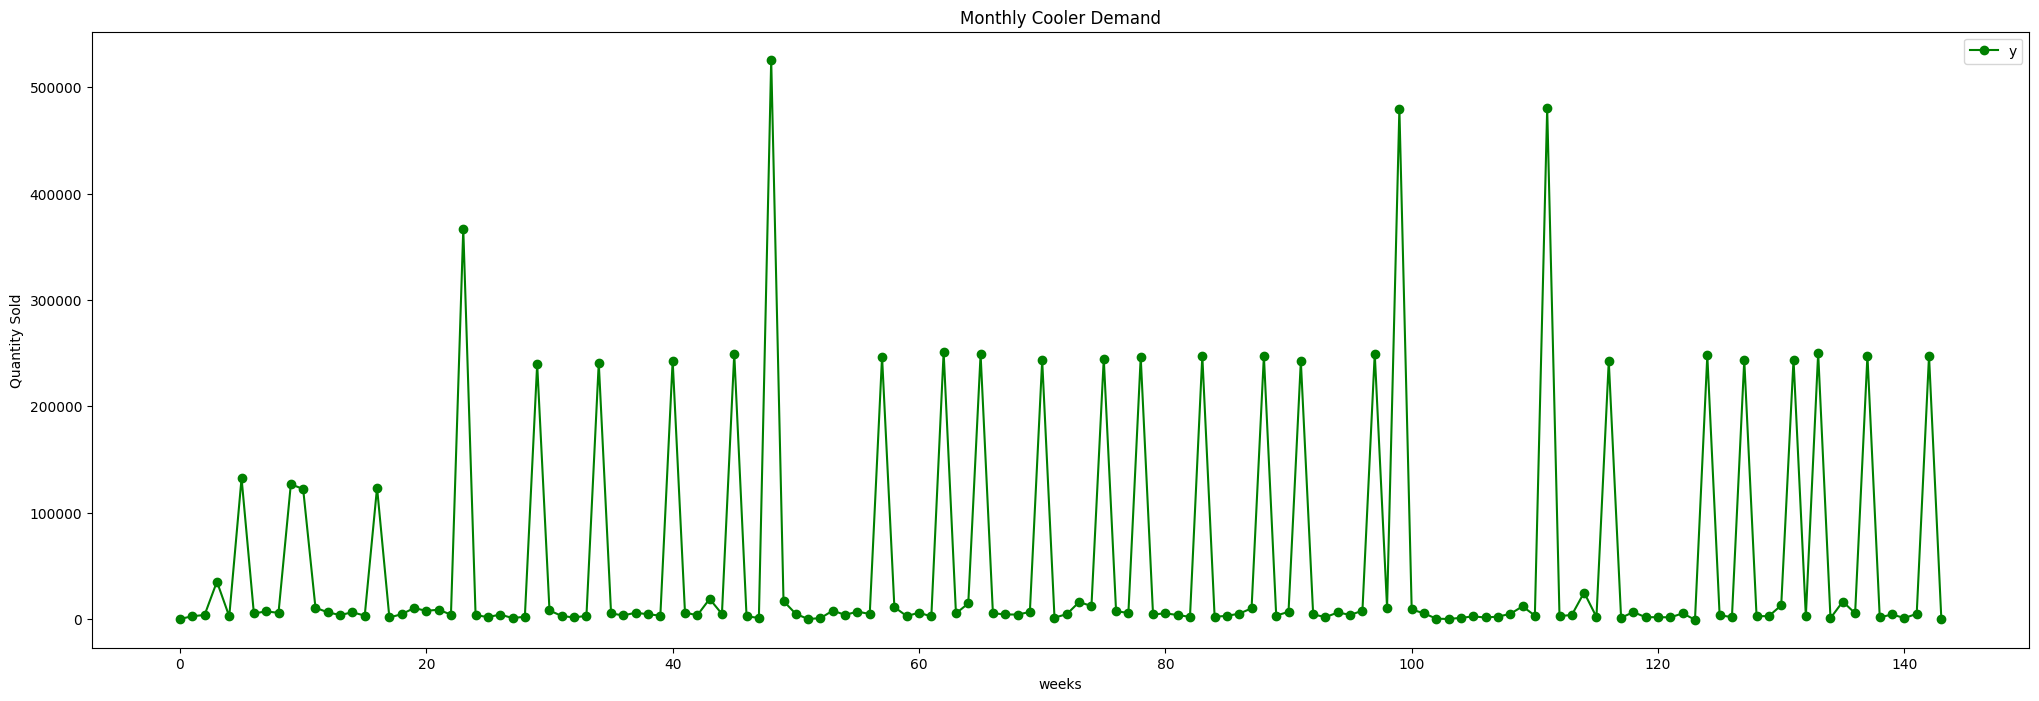

In [99]:
df.plot(kind="line", marker="o", color="green", title="Monthly Cooler Demand", figsize=(25, 8))
plt.xlabel("weeks")
plt.ylabel("Quantity Sold")
plt.show()

In [79]:
df.columns = ["ds", "y"]
df["ds"] = df["ds"].astype(str)
df["ds"] = df["ds"].str.split('/').str[0]
#new_df = new_df.dropna(subset=["ds", "y"])
#new_df["ds"] = pd.to_datetime(new_df["ds"], errors="coerce")

In [480]:
#df["ds"] = pd.to_datetime(new_df["ds"], errors="coerce")
#df = df.dropna(subset=["ds", "y"]) 
#df.to_csv("Oringinal weekly data before fitting into the model.csv") 

In [80]:
df = df[df['y'].notna()]
df["y"].sum()
#df.to_csv("I really wanna see.csv")

np.float64(8123793.029999999)

Prophet

In [81]:
from prophet import Prophet

In [82]:
model = Prophet()

Fitting the values into the model

In [83]:
model.fit(df)

14:59:21 - cmdstanpy - INFO - Chain [1] start processing
14:59:21 - cmdstanpy - INFO - Chain [1] done processing


**Making Future Dates in Prophet**

In [88]:
future_dates = model.make_future_dataframe(periods=54, freq="W") 

In [27]:
df["y"].sum()

np.float64(8123793.029999999)

In [89]:
predictions = model.predict(future_dates)

In [602]:
excel_data = predictions.to_csv("Weekly forecast from prophet after fitting into the model.csv")

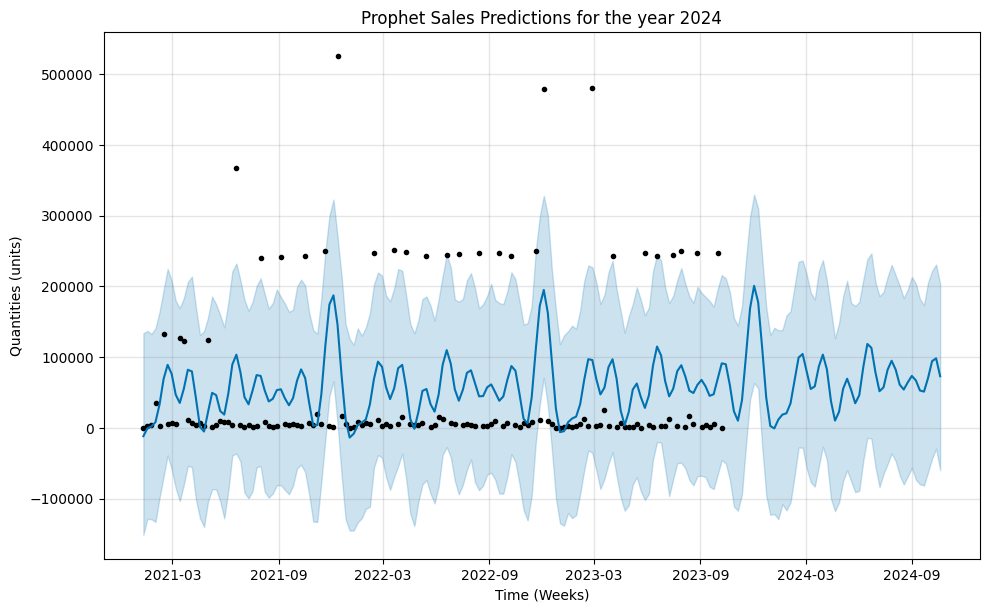

In [90]:
model.plot(predictions)
plt.title("Prophet Sales Predictions for the year 2024")
plt.xlabel("Time (Weeks)")
plt.ylabel("Quantities (units)")
plt.show()

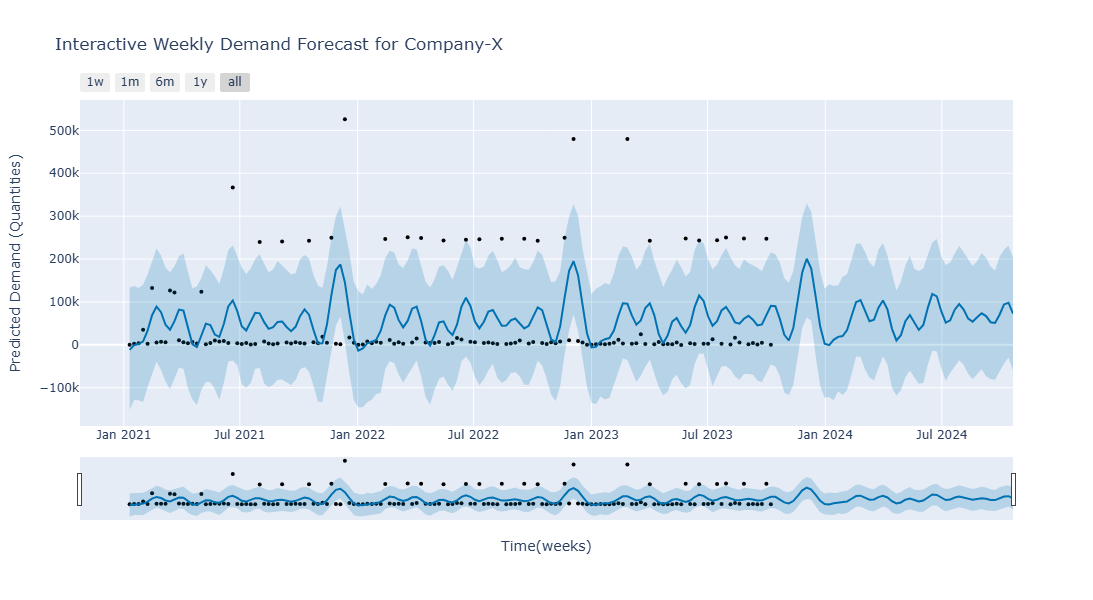

In [91]:
from prophet.plot import plot_plotly

fig = plot_plotly(model, predictions)
fig.update_layout(
    title="Interactive Weekly Demand Forecast for Company-X",
    xaxis_title="Time(weeks)",
    yaxis_title="Predicted Demand (Quantities)",
)
fig.show()

Transferring the model predictions to a csv file

In [ ]:
predictions.to_csv("Prophet_Forecast_Results.csv", index=False)

Visualize each component

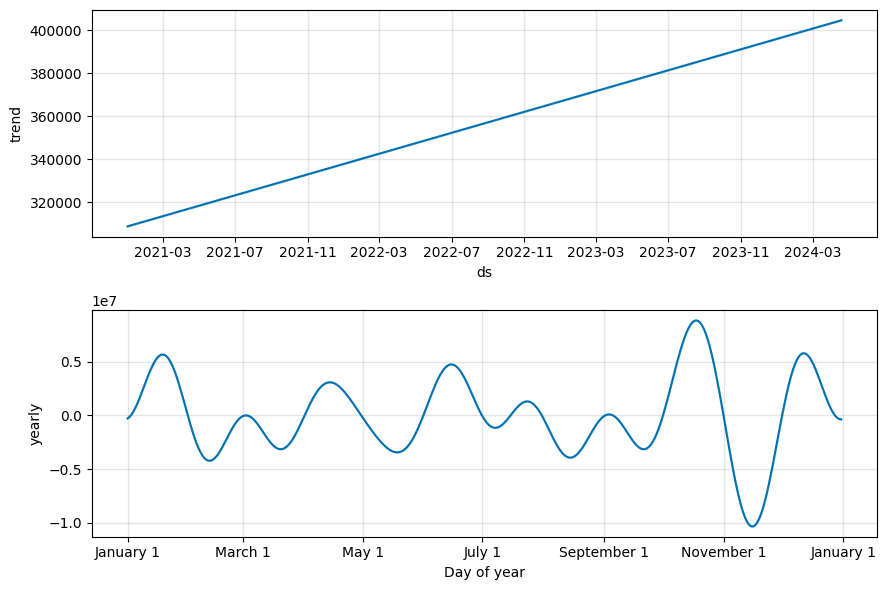

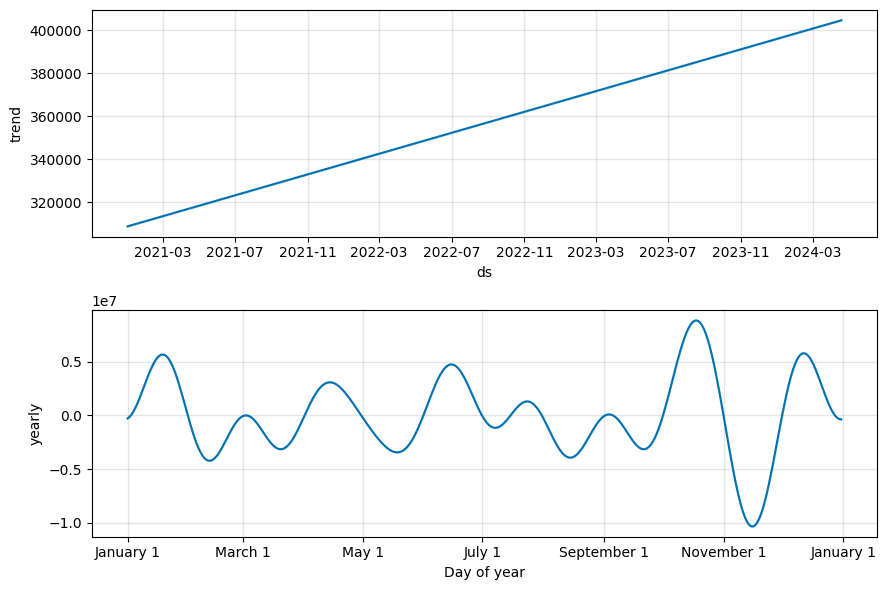

In [639]:
model.plot_components(predictions)

Cross Validation

In [92]:
from prophet.diagnostics import cross_validation

In [93]:
df_cv = cross_validation(model, initial='730 days', period='90 days', horizon='180 days')
excel = df_cv.to_csv("cross-validation values.csv")

  0%|                                                                     | 0/2 [00:00<?, ?it/s]15:01:19 - cmdstanpy - INFO - Chain [1] start processing
15:01:19 - cmdstanpy - INFO - Chain [1] done processing
 50%|██████████████████████████████▌                              | 1/2 [00:00<00:00,  2.08it/s]15:01:19 - cmdstanpy - INFO - Chain [1] start processing
15:01:20 - cmdstanpy - INFO - Chain [1] done processing
100%|█████████████████████████████████████████████████████████████| 2/2 [00:01<00:00,  1.92it/s]


In [94]:
from prophet.diagnostics import performance_metrics

In [95]:
df_P = performance_metrics(df_cv)

In [96]:
df_P.head(5)

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,18 days,6.380360e+08,25259.373995,20540.914531,9.203974,8.754628,1.523659,1.0
1,19 days,9.591177e+08,30969.624771,28207.891770,13.669124,12.178111,1.658158,1.0
2,25 days,1.906253e+09,43660.662919,38104.860319,15.983434,15.126530,1.755462,1.0
3,26 days,3.013287e+09,54893.419005,49945.319995,23.502773,20.794814,1.796436,1.0
4,32 days,4.081360e+09,63885.520694,61987.160670,23.004105,20.794814,1.773985,1.0


In [36]:
df_P.tail(10)

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
38,151 days,2.093107e+10,144675.744707,120732.996237,19.295328,7.713098,1.701252,0.6
39,152 days,1.151261e+10,107296.830888,89835.701071,22.635042,17.625413,1.715022,0.8
40,158 days,5.857552e+09,76534.648542,71665.284963,22.563207,17.625413,1.558729,1.0
41,159 days,6.620319e+09,81365.343744,79800.710836,36.159754,42.866614,1.630796,1.0
42,165 days,9.629532e+09,98130.179995,94327.981398,38.184866,42.866614,1.633914,0.8
43,166 days,8.830336e+09,93969.867362,88027.500560,31.586775,17.625413,1.584383,0.8
44,172 days,9.619109e+09,98077.056527,92583.585100,35.208924,35.736159,1.603946,0.8
45,173 days,1.454170e+10,120588.977614,108889.039124,35.273340,35.736159,1.739853,0.6
46,179 days,1.384951e+10,117683.951272,101948.690603,20.640853,9.876161,1.573682,0.6
47,180 days,1.112640e+10,105481.762461,89402.580031,15441.544490,9.876161,1.587885,0.8


Plotting the cross validation metrics RMSE

In [97]:
from prophet.plot import plot_cross_validation_metric

C:\Users\GIBSON MZIMANDE\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\plot.py:547: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.

C:\Users\GIBSON MZIMANDE\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\plot.py:548: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.



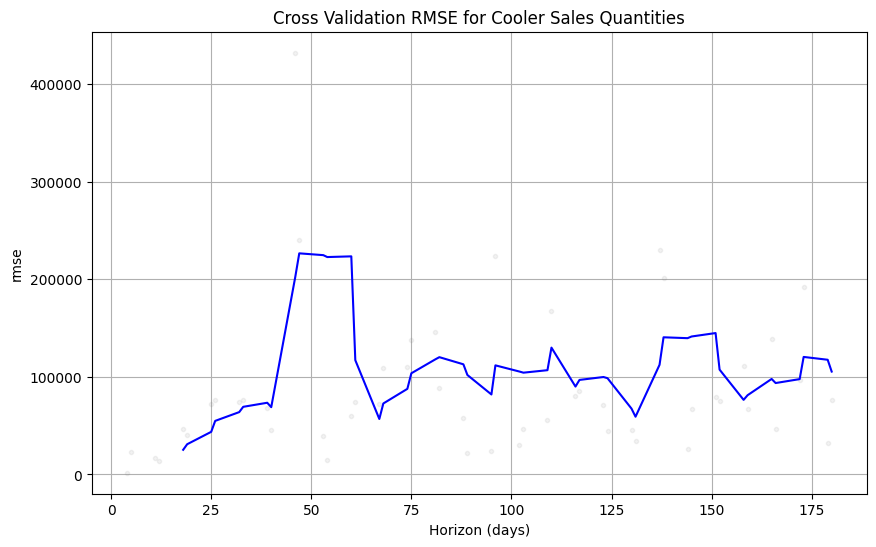

In [98]:
fig = plot_cross_validation_metric(df_cv, metric='rmse')

plt.title("Cross Validation RMSE for Cooler Sales Quantities")
plt.show()